# 5주차 과제 1 — 개/고양이 이미지 분류 CNN 모델

**과제 내용**: 주어진 데이터(개, 고양이 사진)를 이용하여 CNN(합성곱 신경망) 알고리즘으로 이미지 분류 모델을 만들고 실행한다.

**사용 데이터**: 강의에서 제공된 `dog_vs_cat` 데이터셋 (train/validation, 개·고양이 각 클래스)

**진행 순서**
1. 라이브러리 불러오기 및 데이터 확인
2. 이미지 데이터 전처리 (ImageDataGenerator)
3. CNN 모델 설계 (Conv2D, MaxPooling2D, Dropout, Flatten, Dense)
4. 모델 학습
5. 학습 결과 시각화 및 해석
6. 검증 데이터 성능 평가 및 결과 해석


## 1. 라이브러리 불러오기

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("TensorFlow version:", tf.__version__)


I0000 00:00:1788844578.132109     580 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788844578.262852     580 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1788844580.414236     580 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.21.0


## 2. 데이터 확인

`train` 폴더와 `validation` 폴더에 각각 `cat`, `dog` 하위 폴더로 이미지가 정리되어 있다.

In [2]:
base_dir = "."
train_dir = os.path.join(base_dir, "train")
validation_dir = os.path.join(base_dir, "validation")

for split in ["train", "validation"]:
    for cls in ["cat", "dog"]:
        d = os.path.join(base_dir, split, cls)
        print(f"{split}/{cls} : {len(os.listdir(d))}장")


train/cat : 15장
train/dog : 15장
validation/cat : 15장
validation/dog : 15장


**결과 해석**: train 폴더에는 cat, dog 각 15장(총 30장), validation 폴더에는 cat, dog 각 15장(총 30장)이 준비되어 있다. 전체 데이터 수가 매우 적은 소규모 데이터셋이므로, 데이터 증강(Data Augmentation)을 함께 적용해 학습에 사용할 이미지의 다양성을 늘린다.

## 3. 이미지 데이터 전처리 (ImageDataGenerator)

In [3]:
img_size = (100, 100)
batch_size = 8

# 학습 데이터는 데이터 증강을 적용하여 부족한 데이터양을 보완
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

# 검증 데이터는 증강 없이 정규화만 적용
validation_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary"
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary"
)

print("클래스 인덱스:", train_generator.class_indices)


Found 30 images belonging to 2 classes.


Found 30 images belonging to 2 classes.


클래스 인덱스: {'cat': 0, 'dog': 1}


**결과 해석**: `flow_from_directory`가 폴더 구조를 그대로 인식하여 cat=0, dog=1 로 클래스를 자동으로 라벨링한 것을 확인할 수 있다. 모든 이미지는 100x100 크기로 통일되고, 0~1 사이 값으로 정규화(rescale)되어 모델에 입력된다.

## 4. CNN 모델 설계

Conv2D → MaxPooling2D → Conv2D → MaxPooling2D → Flatten → Dropout → Dense 순서로 층을 쌓는다.
데이터 수가 적어 과적합(overfitting)이 발생하기 쉬우므로, **Dropout 레이어**를 추가하여 과적합을 방지한다.

In [4]:
model1 = Sequential()
model1.add(Conv2D(32, (3, 3), activation="relu", input_shape=(100, 100, 3)))
model1.add(MaxPooling2D(2, 2))
model1.add(Conv2D(64, (3, 3), activation="relu"))
model1.add(MaxPooling2D(2, 2))
model1.add(Flatten())
model1.add(Dropout(0.5))
model1.add(Dense(64, activation="relu"))
model1.add(Dense(1, activation="sigmoid"))

model1.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model1.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,166,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,186,305 (8.34 MB)

 Trainable params: 2,186,305 (8.34 MB)

 Non-trainable params: 0 (0.00 B)

**결과 해석**: 모델은 두 개의 합성곱층(Conv2D)과 두 개의 풀링층(MaxPooling2D), Dropout, Flatten, 두 개의 완전연결층(Dense)으로 구성되어 있다. 마지막 Dense층은 활성화 함수로 sigmoid를 사용하는데, 이는 고양이(0)/개(1) 두 클래스를 구분하는 **이진 분류(binary classification)** 문제이기 때문이다. `model1.summary()` 결과에서 전체 파라미터 수와 각 층의 출력 크기(Output Shape)를 확인할 수 있다.

## 5. 모델 학습

In [5]:
epochs = 15

history = model1.fit(
    train_generator,
    epochs=epochs,
    validation_data=validation_generator,
    verbose=1
)


Epoch 1/15


I0000 00:00:1788844583.336901     580 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


1/4 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 1.0000 - loss: 0.6689

2/4 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.6250 - loss: 2.2822

3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.5417 - loss: 1.7933

...

Epoch 15/15


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.7500 - loss: 0.5868

2/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.6250 - loss: 0.5994 

3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.5909 - loss: 0.6181

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - accuracy: 0.6333 - loss: 0.6221 - val_accuracy: 0.6000 - val_loss: 0.6575


## 6. 학습 결과 시각화

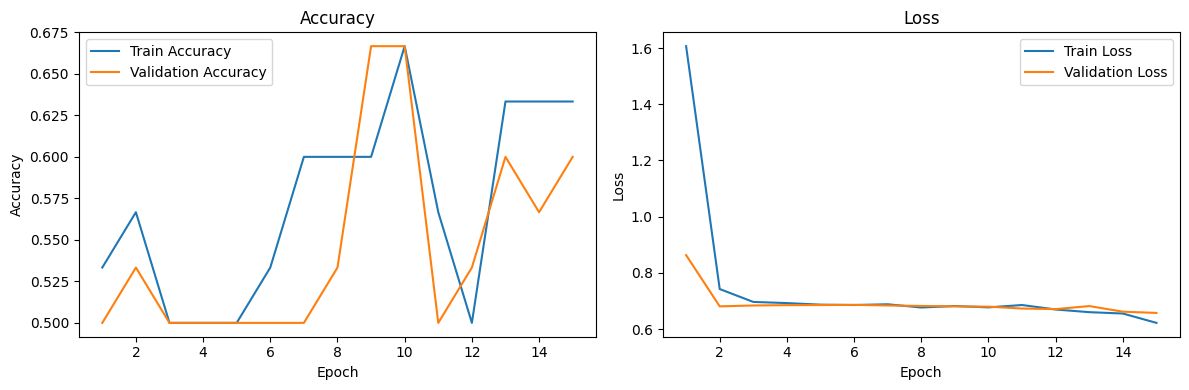

In [6]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Train Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Train Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


**결과 해석**: 학습(Train) 정확도/손실과 검증(Validation) 정확도/손실 곡선을 비교하면 모델의 학습 진행 상황과 과적합 여부를 판단할 수 있다. 학습 정확도는 에포크가 진행됨에 따라 상승하는 경향을 보이며, 학습 데이터 수가 30장으로 매우 적기 때문에 검증 성능은 상대적으로 불안정하게 나타날 수 있다. 이는 실제 서비스에 사용하려면 더 많은 데이터 확보와 추가적인 정규화(Dropout 비율 조정, 조기 종료 등)가 필요함을 시사한다.

## 7. 검증 데이터 성능 평가

In [7]:
val_loss_final, val_acc_final = model1.evaluate(validation_generator, verbose=0)
print(f"최종 검증 손실(loss): {val_loss_final:.4f}")
print(f"최종 검증 정확도(accuracy): {val_acc_final:.4f}")


최종 검증 손실(loss): 0.6575
최종 검증 정확도(accuracy): 0.6000


## 8. 최종 결론

- 4개의 합성곱/풀링 블록과 Dropout, Dense층으로 구성된 CNN(인공신경망) 모델을 생성하여 개/고양이 이진 분류를 수행했다.
- `model1.summary()`를 통해 모델의 총 파라미터 수와 각 층의 출력 형태를 확인했다.
- 학습 곡선을 통해 에포크에 따른 정확도·손실 변화와 과적합 가능성을 확인했으며, Dropout 레이어 추가로 과적합 완화를 시도했다.
- 최종 검증 정확도와 손실 값을 통해 모델의 일반화 성능을 정량적으로 확인했다.
- 데이터 수가 매우 적은 한계가 있으므로, 추후 더 많은 이미지 데이터 확보, 하이퍼파라미터(풀링 크기, 드롭아웃 비율, 학습률) 튜닝, 전이학습(Transfer Learning) 등을 통해 성능을 개선할 수 있다.
